### Deep learning model training.
#### Top accuracy(inner 256x256):
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|89.7%|92.9%|20260316|    
|U2Net|89.8%|93.2%|20260216|    
|U2Net_cbam|89.8%|93.4%|20260307|    
|U2Net_biatt|89.9%|93.1%|20260306|    
|||||    

#### Top accuracy(full patch size：448x448):
|model|miou|oa|update_time|    
|----|----|----|----|   
|UNet|80.3%|86.1%|20260428|    
|U2Net|90.6%|94.4%|20260427|    
|U2Net_cbam|90.6%|94.5%|20260428|    
|U2Net_biatt|90.7%|95.9%|20260428|    
|||||  


#### Top accuracy(full patch size：512x512):
|model|miou|oa|update_time||    
|----|----|----|----|---|
|UNet|92.8%|96.2%|20260309|difficult to train|    
|U2Net|90.1%|97.9%|20260524|batch_size_tra=4|    
|U2Net|92.7%|98.4%|20260524|batch_size_tra=16|    
|U2Net_cbam|93.3%|98.6%|20260524|batch_size_tra=16|    
|U2Net_biatt|92.9%|98.5%|20260524|batch_size_tra=16|    
|||||    


### conclusions:   
1. larger patch size achieves better performance.
2. the bn params should be frozen or remove bn layer  when train unet. 



In [1]:
import time
import torch
import random
import pandas as pd
import torch.nn as nn
from glob import glob
from notebooks import config
import torch.nn.functional as F
import matplotlib.pyplot as plt
from utils.imgShow import imsShow
from torchvision.transforms import v2
from utils.data_aug import GaussianNoise
from utils.dataloader import read_scenes 
from utils.metrics import oa_binary, miou_binary
from utils.dataloader import SceneArraySet, PatchPathSet
from model import unet, u2net_biatt, u2net, u2net_cbam
from torchmetrics.classification import BinaryJaccardIndex, BinaryAccuracy


In [2]:
patch_size = 512  ## patch size setting
batch_size_tra = 16  ## batch size setting, better than set to 4. 
batch_size_val = 16  ## batch size setting
patch_resize = None  ## patch resize setting
device = torch.device('cuda:0')  
### traset
paths_scene_tra, paths_truth_tra = config.paths_scene_tra, config.paths_truth_tra
paths_dem_tra = config.paths_dem_tra
print(f'train scenes: {len(paths_scene_tra)}')
## valset
paths_valset = sorted(glob(f'data/dset/valset/patch_{patch_size}/*'))  ## for model prediction 
print(f'vali patch {patch_size}: {len(paths_valset)}')


train scenes: 52
vali patch 512: 117


### dataset loading

In [3]:
scenes_arr, truths_arr = read_scenes(paths_scene_tra, 
                                     paths_truth_tra, 
                                     paths_dem_tra) 


In [4]:
transforms_tra = v2.Compose([   
            v2.ToImage(),   
            v2.RandomCrop(size=(patch_size, patch_size)),   
            v2.RandomHorizontalFlip(p=0.3),   
            v2.RandomVerticalFlip(p=0.3),   
            v2.RandomApply([v2.RandomRotation(degrees=15)], p=0.3),  
            GaussianNoise(mean = 0.0, sigma_max_img=0.1, sigma_max_dem=0, p=0.3)  
            ]) 
transforms_val = v2.Compose([
      v2.ToDtype(torch.float32),
       ])   


In [5]:
# Create dataset instances
tra_data = SceneArraySet(scenes_arr=scenes_arr, truths_arr=truths_arr, 
                              patch_size=patch_size, transforms=transforms_tra)
val_data = PatchPathSet(paths_valset=paths_valset, transforms=transforms_val)

## Create data loaders
tra_loader = torch.utils.data.DataLoader(tra_data, batch_size=batch_size_tra, 
                                         shuffle=True, num_workers=5)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=batch_size_val, num_workers=5)



#### Model training

In [6]:
### check model
# model = unet(num_bands=7)
# model = u2net(num_bands_b1=6, num_bands_b2=1)
# model = u2net_cbam(num_bands_b1=6, num_bands_b2=1)
# model = u2net_att_1(num_bands_b1=6, num_bands_b2=1)
model = u2net_biatt(num_bands_b1=6, num_bands_b2=1)
# model = u2net_edgeatt(num_bands_b1=6, num_bands_b2=1) 


In [7]:
input_tensor = torch.randn(2, 7, 512, 512) 
output = model(input_tensor)  
print(output.shape) 


torch.Size([2, 1, 512, 512])


In [8]:
### create loss and optimizer
# loss_bce = nn.BCELoss()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)  
# lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, \
#                                       mode='max', 
#                                       factor=0.5, 
#                                       patience=10,
#                                       min_lr=1e-5)


In [9]:
'''------train loops------'''
def train_loops(model, loss_fn, 
                    optimizer, 
                    tra_loader, 
                    val_loader,                     
                    epoches, 
                    device, 
                    lr_scheduler=None):
    loss_tra_loops, miou_tra_loops, oa_tra_loops = [], [], []
    loss_val_loops, miou_val_loops, oa_val_loops = [], [], []
    model = model.to(device)
    size_tra_loader = len(tra_loader)
    size_val_loader = len(val_loader)
    for epoch in range(epoches):
        start = time.time()
        loss_tra, loss_val = 0, 0
        '''-----train the model-----'''
        miou_tra = BinaryJaccardIndex().to(device)
        oa_tra = BinaryAccuracy().to(device)
        model.train()   # training mode for dropout and batchnorm
        for x_batch, y_batch in tra_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            pred = (F.sigmoid(pred) > 0.5).float()
            miou_tra.update(pred, y_batch.long())
            oa_tra.update(pred, y_batch.long())
            loss_tra += loss.item()
        miou_tra_global = miou_tra.compute()
        oa_tra_global = oa_tra.compute()
        loss_tra_global = loss_tra/size_tra_loader
        miou_tra.reset(); oa_tra.reset()

        '''----- validation the model: time consuming -----'''
        oa_val = BinaryAccuracy().to(device)
        miou_val = BinaryJaccardIndex().to(device)
        model.eval()
        if epoch>500 and (epoch+1) % 3 == 0: 
            for x_batch, y_batch in val_loader:
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                with torch.no_grad():
                    pred = model(x_batch)
                    # if x.shape[2] > 256:  ### crop inner 256x256 for evaluation
                    #     pred = v2.functional.center_crop(pred, 256)
                    #     y = v2.functional.center_crop(y, 256)
                    loss = loss_fn(pred, y_batch)
                pred = (F.sigmoid(pred) > 0.5).float()
                miou_val.update(pred, y_batch.long())
                oa_val.update(pred, y_batch.long())
                loss_val += loss.item()
            miou_val_global = miou_val.compute()
            oa_val_global = oa_val.compute()
            loss_val_global = loss_val/size_val_loader
            miou_val.reset(); oa_val.reset()

            loss_tra_loops.append(loss_tra_global); miou_tra_loops.append(miou_tra_global); oa_tra_loops.append(oa_tra_global)
            loss_val_loops.append(loss_val_global); miou_val_loops.append(miou_val_global); oa_val_loops.append(oa_val_global)
            print(f'Ep{epoch}: tra-> Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, '
                    f'val-> Loss:{loss_val_global:.3f},Oa:{oa_val_global:.3f}, Miou:{miou_val_global:.3f},time:{time.time()-start:.1f}s')
        else: 
            print(f'Ep{epoch}: tra->Loss:{loss_tra_global:.3f},Oa:{oa_tra_global:.3f},Miou:{miou_tra_global:.3f}, \
                                time:{time.time()-start:.1f}s')
        if lr_scheduler:
          lr_scheduler.step(miou_tra_global)    ## if use lr_scheduler like ReduceLROnPlateau
        ## show the result
        if (epoch+1)%200 == 0:
            sam_index = random.randrange(len(val_data))
            patch, truth = val_data[sam_index]
            patch, truth = patch.unsqueeze(0).to(device), truth.to(device)
            pred = model(patch)
            pred = F.sigmoid(pred)  ## convert logit to prob for metric calculation
            if patch.shape[2] > 256:  ## zoom in for visualization if patch size > 256
                pred_val = v2.functional.center_crop(pred, 256)
                patch_val = v2.functional.center_crop(patch, 256)
                truth_val = v2.functional.center_crop(truth, 256)
            else:
                patch_val = patch
                pred_val = pred
                truth_val = truth
            ## convert to numpy and plot
            patch = patch[0].to('cpu').detach().numpy().transpose(1,2,0)            
            pred = pred[0].to('cpu').detach().numpy()
            patch_val = patch_val[0].to('cpu').detach().numpy().transpose(1,2,0)
            pred_val = pred_val[0].to('cpu').detach().numpy()
            truth_val = truth_val.to('cpu').detach().numpy()
            imsShow([patch, pred, patch_val, pred_val, truth_val], 
                    clip_list = (2,0,2,0,0),
                    img_name_list=['input_patch', 'pred', 'patch_zoom_in', 'pred_zoom_in', 'truth_zoom_in'], 
                    figsize=(15, 3))
            plt.tight_layout() 
    metrics = {'tra_loss':loss_tra_loops, 'tra_oa': oa_tra_loops, 'tra_miou': miou_tra_loops,
                'val_loss': loss_val_loops, 'val_oa': oa_val_loops, 'val_miou': miou_val_loops}
    return metrics 


Ep0: tra->Loss:0.689,Oa:0.514,Miou:0.308,                                 time:2.1s
Ep1: tra->Loss:0.650,Oa:0.934,Miou:0.770,                                 time:1.7s
Ep2: tra->Loss:0.573,Oa:0.944,Miou:0.810,                                 time:1.6s
Ep3: tra->Loss:0.428,Oa:0.934,Miou:0.769,                                 time:1.7s
Ep4: tra->Loss:0.250,Oa:0.944,Miou:0.775,                                 time:1.6s
Ep5: tra->Loss:0.222,Oa:0.928,Miou:0.772,                                 time:1.8s
Ep6: tra->Loss:0.178,Oa:0.946,Miou:0.789,                                 time:1.6s
Ep7: tra->Loss:0.200,Oa:0.937,Miou:0.778,                                 time:1.7s
Ep8: tra->Loss:0.171,Oa:0.939,Miou:0.791,                                 time:1.9s
Ep9: tra->Loss:0.182,Oa:0.943,Miou:0.767,                                 time:1.9s
Ep10: tra->Loss:0.201,Oa:0.937,Miou:0.795,                                 time:1.9s
Ep11: tra->Loss:0.130,Oa:0.958,Miou:0.828,                                 

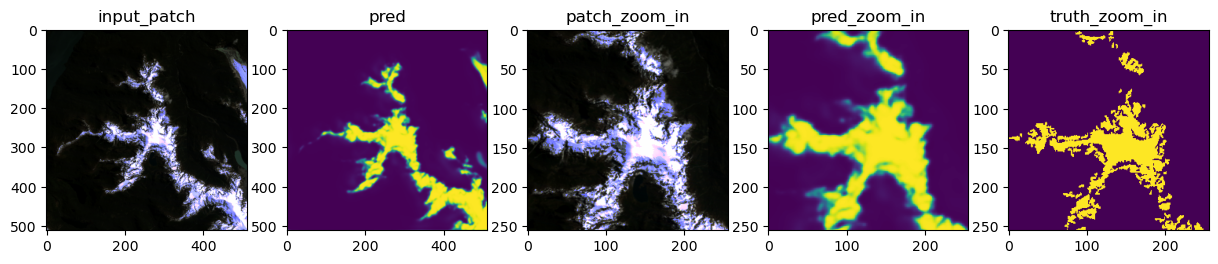

Ep200: tra->Loss:0.038,Oa:0.983,Miou:0.927,                                 time:2.2s
Ep201: tra->Loss:0.044,Oa:0.987,Miou:0.937,                                 time:1.9s
Ep202: tra->Loss:0.041,Oa:0.986,Miou:0.941,                                 time:1.9s
Ep203: tra->Loss:0.042,Oa:0.981,Miou:0.920,                                 time:2.1s
Ep204: tra->Loss:0.048,Oa:0.981,Miou:0.923,                                 time:2.1s
Ep205: tra->Loss:0.052,Oa:0.979,Miou:0.919,                                 time:2.2s
Ep206: tra->Loss:0.056,Oa:0.979,Miou:0.927,                                 time:2.1s
Ep207: tra->Loss:0.060,Oa:0.972,Miou:0.875,                                 time:2.2s
Ep208: tra->Loss:0.044,Oa:0.982,Miou:0.935,                                 time:2.2s
Ep209: tra->Loss:0.069,Oa:0.982,Miou:0.915,                                 time:2.2s
Ep210: tra->Loss:0.044,Oa:0.983,Miou:0.938,                                 time:2.3s
Ep211: tra->Loss:0.049,Oa:0.978,Miou:0.916,           

<Figure size 640x480 with 0 Axes>

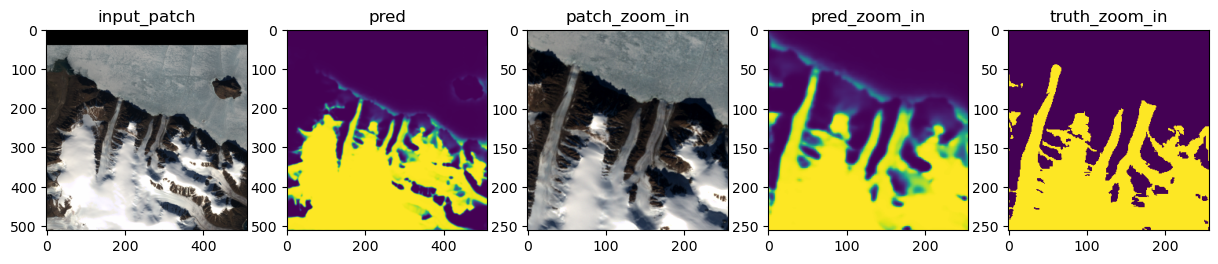

Ep400: tra->Loss:0.034,Oa:0.986,Miou:0.950,                                 time:2.1s
Ep401: tra->Loss:0.038,Oa:0.985,Miou:0.946,                                 time:1.9s
Ep402: tra->Loss:0.036,Oa:0.986,Miou:0.944,                                 time:2.3s
Ep403: tra->Loss:0.042,Oa:0.984,Miou:0.932,                                 time:2.1s
Ep404: tra->Loss:0.035,Oa:0.986,Miou:0.948,                                 time:2.2s
Ep405: tra->Loss:0.031,Oa:0.987,Miou:0.952,                                 time:2.2s
Ep406: tra->Loss:0.029,Oa:0.988,Miou:0.960,                                 time:2.2s
Ep407: tra->Loss:0.033,Oa:0.986,Miou:0.945,                                 time:1.9s
Ep408: tra->Loss:0.039,Oa:0.987,Miou:0.942,                                 time:2.2s
Ep409: tra->Loss:0.040,Oa:0.983,Miou:0.935,                                 time:1.7s
Ep410: tra->Loss:0.036,Oa:0.989,Miou:0.947,                                 time:1.7s
Ep411: tra->Loss:0.042,Oa:0.986,Miou:0.939,           

<Figure size 640x480 with 0 Axes>

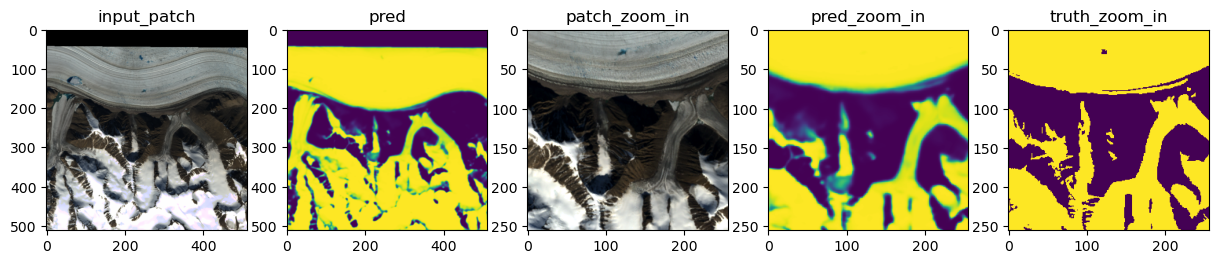

Ep600: tra->Loss:0.041,Oa:0.984,Miou:0.916,                                 time:2.5s
Ep601: tra->Loss:0.077,Oa:0.977,Miou:0.916,                                 time:2.2s
Ep602: tra-> Loss:0.041,Oa:0.983,Miou:0.930, val-> Loss:0.062,Oa:0.978, Miou:0.896,time:3.7s
Ep603: tra->Loss:0.088,Oa:0.980,Miou:0.926,                                 time:2.3s
Ep604: tra->Loss:0.035,Oa:0.984,Miou:0.938,                                 time:2.3s
Ep605: tra-> Loss:0.033,Oa:0.985,Miou:0.944, val-> Loss:0.160,Oa:0.959, Miou:0.829,time:3.3s
Ep606: tra->Loss:0.037,Oa:0.982,Miou:0.942,                                 time:1.7s
Ep607: tra->Loss:0.037,Oa:0.987,Miou:0.947,                                 time:2.0s
Ep608: tra-> Loss:0.058,Oa:0.973,Miou:0.897, val-> Loss:0.045,Oa:0.982, Miou:0.916,time:3.5s
Ep609: tra->Loss:0.030,Oa:0.988,Miou:0.956,                                 time:2.1s
Ep610: tra->Loss:0.038,Oa:0.985,Miou:0.948,                                 time:1.9s
Ep611: tra-> Loss:0.048,Oa:0.985,

<Figure size 640x480 with 0 Axes>

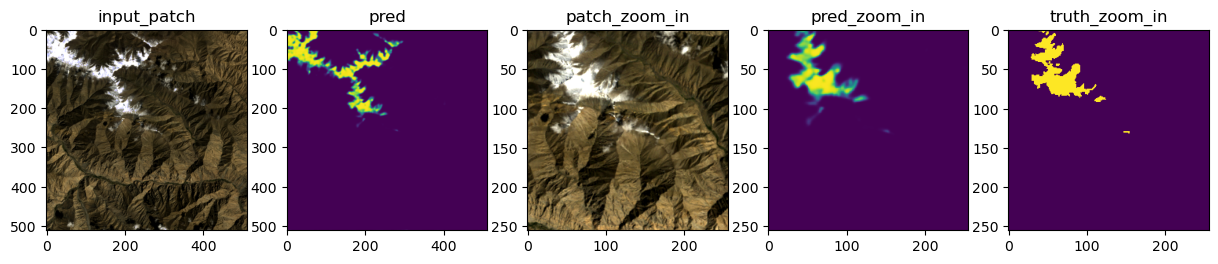

Ep800: tra-> Loss:0.030,Oa:0.986,Miou:0.948, val-> Loss:0.039,Oa:0.984, Miou:0.925,time:3.5s
Ep801: tra->Loss:0.033,Oa:0.986,Miou:0.936,                                 time:2.1s
Ep802: tra->Loss:0.034,Oa:0.988,Miou:0.948,                                 time:2.0s
Ep803: tra-> Loss:0.030,Oa:0.988,Miou:0.955, val-> Loss:0.043,Oa:0.983, Miou:0.921,time:3.3s
Ep804: tra->Loss:0.041,Oa:0.987,Miou:0.948,                                 time:2.0s
Ep805: tra->Loss:0.041,Oa:0.987,Miou:0.941,                                 time:2.3s
Ep806: tra-> Loss:0.030,Oa:0.987,Miou:0.941, val-> Loss:0.039,Oa:0.985, Miou:0.926,time:3.9s
Ep807: tra->Loss:0.067,Oa:0.983,Miou:0.933,                                 time:2.1s
Ep808: tra->Loss:0.043,Oa:0.985,Miou:0.944,                                 time:1.9s
Ep809: tra-> Loss:0.040,Oa:0.986,Miou:0.939, val-> Loss:0.048,Oa:0.981, Miou:0.915,time:3.7s
Ep810: tra->Loss:0.023,Oa:0.991,Miou:0.958,                                 time:2.2s
Ep811: tra->Loss:0.033,Oa:

<Figure size 640x480 with 0 Axes>

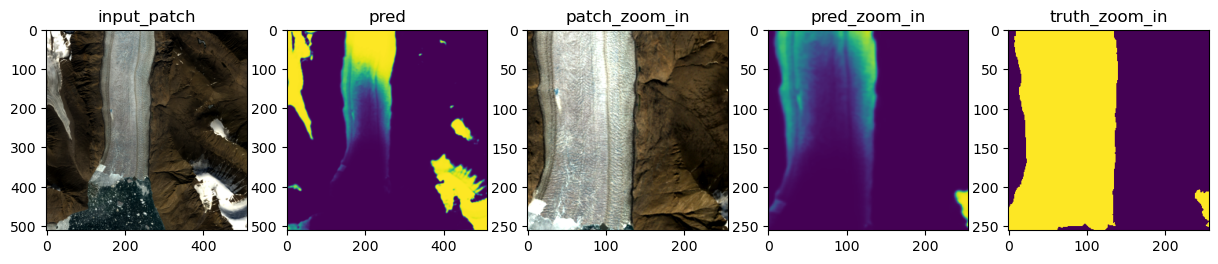

<Figure size 640x480 with 0 Axes>

In [10]:

metrics = train_loops(model=model,  
                epoches=1000,  
                loss_fn=criterion,  
                optimizer=optimizer,  
                tra_loader=tra_loader,  
                val_loader=val_loader,  
                # lr_scheduler=lr_scheduler,  
                device=device)  


In [ ]:
# # model saving 
# model_name = 'u2net' 
# # model_name = 'u2net_biatt' 
# # model_name = 'u2net_cbam' 
# # model_name = 'deeplabv3plus'  
# # model_name = 'deeplabv3plus_mb2' 
# date_str = time.strftime("%Y-%m-%d-%H", time.localtime()) 
# date_str = date_str.replace('-', '')  ## remove '-' for file name 
# path_save = f'model/trained/{model_name}/{model_name}_eval_mode.pth' 
# # path_save = f'model/trained/seg_models/{model_name}_weights_{date_str}.pth' 
# torch.save(model.state_dict(), path_save)     ## save weights of the trained model 
# ## model.load_state_dict(torch.load(path_save, weights_only=True))  ## load the weights of the trained model
# ## metrics saving
# path_metrics = f'model/trained/{model_name}/{model_name}_eval_mode_metrics.csv'    
# ## path_metrics = f'model/trained/seg_models/{model_name}_metrics_{date_str}.csv'    
# metrics_df = pd.DataFrame(metrics)
# metrics_df.to_csv(path_metrics, index=False, sep=',')
